# MARL-mixed — multi-agent learning dynamics

This notebook summarizes the experiments added to **MARL-mixed**:

1. **JaxMARL sweep** — IPPO trained on *every registered JaxMARL environment*
   (one SLURM array task per game, GPU each), logging the learning dynamics.
2. **CRLD observability study** — the 2-agent / N-agent Iterated Prisoner's
   Dilemma with heterogeneous observability (deterministic learning dynamics).

Everything below is generated from saved artifacts in `results/` — no training
or GPU needed to re-run the notebook.

In [1]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
RESULTS = os.path.join(HERE, "results")
REPO = os.path.dirname(HERE)
pd.set_option("display.max_rows", 100)
print("results dir:", RESULTS)

results dir: /nas/ucb/marimeireles/MARL-mixed/jaxmarl_env/results


## 1. Coverage across all JaxMARL environments

Each environment produced a `.status` file (`ok` / `skipped:<reason>` /
`failed:<reason>`). A single feed-forward, **discrete-action** IPPO trains the
discrete games directly; continuous-action games need a Gaussian policy head
(added separately) and a few image/dict-observation games need a CNN encoder.

In [2]:
rows = []
for s in sorted(glob.glob(os.path.join(RESULTS, "*.status"))):
    env = os.path.basename(s)[:-7]
    st = open(s).read().strip()
    kind = st.split(":", 1)[0]
    reason = st.split(":", 1)[1] if ":" in st else ""
    rows.append(dict(environment=env, status=kind, reason=reason))
cov = pd.DataFrame(rows)
summary = cov["status"].value_counts().rename("count").to_frame()
print(summary)
cov

         count
status        
ok          14
skipped     11
failed       5


,environment,status,reason
0,HeuristicEnemySMAX,ok,
1,LearnedPolicyEnemySMAX,failed,"TypeError(""LearnedPolicyEnemySMAX.__init__() m..."
2,MPE_simple_adversary_v3,ok,
3,MPE_simple_crypto_v3,ok,
4,MPE_simple_facmac_3a_v1,skipped,continuous action space (needs Gaussian policy)
5,MPE_simple_facmac_6a_v1,skipped,continuous action space (needs Gaussian policy)
6,MPE_simple_facmac_9a_v1,skipped,continuous action space (needs Gaussian policy)
7,MPE_simple_facmac_v1,skipped,continuous action space (needs Gaussian policy)
8,MPE_simple_push_v3,ok,
9,MPE_simple_reference_v3,ok,


## 2. Learning dynamics of the trained games

Reward per step vs. environment steps. Most games show clear improvement; hard exploration games (SMAX) stay near flat at this budget.

In [3]:
trained = []
for f in sorted(glob.glob(os.path.join(RESULTS, "*.npz"))):
    d = np.load(f)
    env = os.path.basename(f)[:-4]
    y = d["dynamics"]
    trained.append(dict(environment=env,
                        n_agents=int(d["num_agents"]),
                        reward_start=round(float(y[0]), 3),
                        reward_end=round(float(y[-1]), 3),
                        delta=round(float(y[-1] - y[0]), 3),
                        updates=len(y)))
perf = pd.DataFrame(trained).sort_values("delta", ascending=False).reset_index(drop=True)
perf

,environment,n_agents,reward_start,reward_end,delta,updates
0,MPE_simple_v3,1,-1.561,-0.259,1.302,610
1,MPE_simple_speaker_listener_v4,2,-1.467,-0.592,0.875,610
2,overcooked,2,0.000,0.623,0.623,610
3,MPE_simple_reference_v3,2,-1.109,-0.685,0.424,610
4,MPE_simple_push_v3,2,-0.576,-0.289,0.288,610
5,MPE_simple_spread_v3,3,-1.071,-0.786,0.285,610
6,MPE_simple_tag_v3,4,-0.043,0.212,0.255,610
7,switch_riddle,3,-0.225,0.000,0.225,610
8,MPE_simple_adversary_v3,3,-0.185,-0.028,0.157,610
9,hanabi,2,0.006,0.048,0.043,610


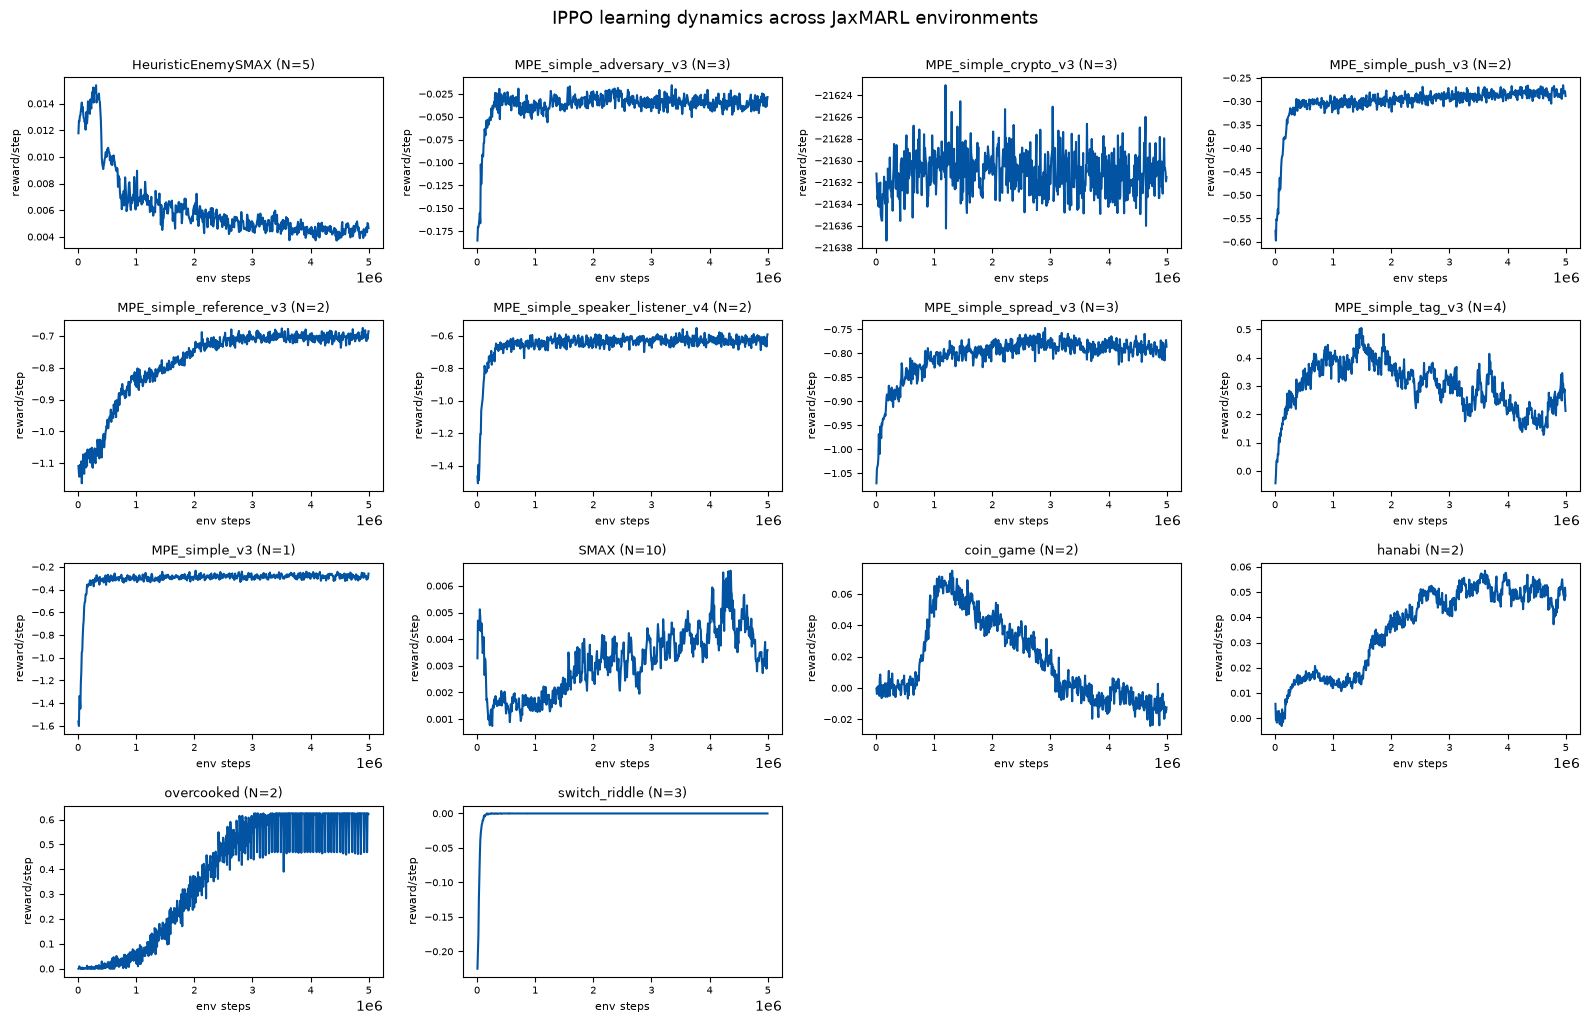

In [4]:
files = sorted(glob.glob(os.path.join(RESULTS, "*.npz")))
ncol = 4; nrow = (len(files) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 2.6*nrow), squeeze=False)
for ax in axes.flat: ax.axis("off")
for k, f in enumerate(files):
    d = np.load(f); ax = axes[k//ncol][k%ncol]; ax.axis("on")
    ax.plot(d["timesteps"], d["dynamics"], color="#0254a3")
    ax.set_title(f"{os.path.basename(f)[:-4]} (N={int(d['num_agents'])})", fontsize=9)
    ax.set_xlabel("env steps", fontsize=8); ax.set_ylabel("reward/step", fontsize=8)
    ax.tick_params(labelsize=7)
fig.suptitle("IPPO learning dynamics across JaxMARL environments", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()

### Skipped & failed — and why

- **skipped: continuous action space** — MaBrax robotic-control envs and the
  FACMAC MPE variants use `Box` actions; handled by the Gaussian-policy run
  (Section 4).
- **failed** — environment-specific API quirks (dict/image observations, a
  `make()` that needs extra args). Each is a localized follow-up.

In [5]:
notok = cov[cov.status != "ok"][["environment", "status", "reason"]]
notok.reset_index(drop=True)

,environment,status,reason
0,LearnedPolicyEnemySMAX,failed,"TypeError(""LearnedPolicyEnemySMAX.__init__() m..."
1,MPE_simple_facmac_3a_v1,skipped,continuous action space (needs Gaussian policy)
2,MPE_simple_facmac_6a_v1,skipped,continuous action space (needs Gaussian policy)
3,MPE_simple_facmac_9a_v1,skipped,continuous action space (needs Gaussian policy)
4,MPE_simple_facmac_v1,skipped,continuous action space (needs Gaussian policy)
5,MPE_simple_world_comm_v3,skipped,continuous action space (needs Gaussian policy)
6,ant_4x2,skipped,continuous action space (needs Gaussian policy)
7,halfcheetah_6x1,skipped,continuous action space (needs Gaussian policy)
8,hopper_3x1,skipped,continuous action space (needs Gaussian policy)
9,humanoid_9|8,skipped,continuous action space (needs Gaussian policy)


## 3. Continuous control (MaBrax) — Gaussian policy

The discrete sweep above skips `Box`-action games. A Gaussian policy head lets
IPPO train the MaBrax robotic-control suite (`ant_4x2`, `halfcheetah_6x1`,
`hopper_3x1`, `humanoid_9|8`, `walker2d_2x3`). Their curves are loaded below once
that run has completed (look for `*_mabrax` / continuous entries in the table
above).

*This section auto-populates from the same `results/` directory, so re-running
the notebook after the MaBrax sweep finishes will show the new curves with no
code changes.*

In [6]:
mabrax = [r for r in trained if r["environment"] in
          {"ant_4x2","halfcheetah_6x1","hopper_3x1","humanoid_9|8","walker2d_2x3"}]
if mabrax:
    display(pd.DataFrame(mabrax))
else:
    print("MaBrax continuous results not present yet — run the Gaussian sweep, "
          "then re-execute this notebook.")

MaBrax continuous results not present yet — run the Gaussian sweep, then re-execute this notebook.


## 4. CRLD observability study (the original research question)

Before the deep-RL sweep, the core study uses **collective reinforcement
learning dynamics** (CRLD, the deterministic learning-dynamics limit) on the
Iterated Prisoner's Dilemma with *heterogeneous observability*: one agent sees
the full interaction, the other is selectively blind.

Key reproduced finding: **cooperation is fragile** — defection is the modal
attractor, and impairing observability suppresses cooperation monotonically;
losing the ability to observe one's *own* last action is uniquely catastrophic.

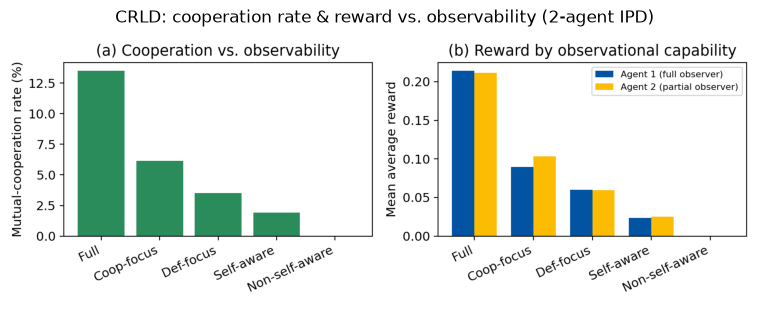

In [7]:
summ = os.path.join(REPO, "paper", "figures", "summary.png")
if os.path.exists(summ):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(11, 3.6)); ax.imshow(mpimg.imread(summ)); ax.axis("off")
    ax.set_title("CRLD: cooperation rate & reward vs. observability (2-agent IPD)")
    plt.show()
else:
    print("summary figure not found:", summ)

In [8]:
# N-agent extension: cooperation rate as a function of #agents x regime
csv = os.path.join(HERE, "coop_table.csv")
if os.path.exists(csv):
    display(pd.read_csv(csv))
else:
    print("coop_table.csv not found")

,regime,N=2,N=3,N=4
0,full,0.0,0.0,0.0
1,blind,0.0,0.0,0.0
2,self,0.0,0.0,0.0
3,others,0.0,0.0,0.0


## 5. What was added to this repository

| path | what it is |
|---|---|
| `jaxmarl_env/heterogeneous_ipd.py` | N-player memory-1 IPD as a JaxMARL `MultiAgentEnv`, 6 observability regimes |
| `jaxmarl_env/train_ippo.py` | shared-policy feed-forward IPPO for the IPD (discrete) |
| `jaxmarl_env/run_all.py` | generic IPPO driver: trains one JaxMARL env, logs dynamics (discrete **and** Gaussian-continuous) |
| `jaxmarl_env/slurm_sweep.sh` | SLURM array job — one task per registered env |
| `jaxmarl_env/plot_all.py` | coverage report + combined dynamics grid |
| `jaxmarl_env/sweep_table.py` | regime x N cooperation table for the IPD |
| `jaxmarl_env/results/` | per-env `.npz` curves, `.png`, `.status` |
| `scratch_repro/` | CRLD reproduction scripts (deterministic IPD dynamics) |
| `paper/` | corrected write-up + regenerated figures |
| `.venv-jaxmarl/` | Python 3.11 env (uv) with JaxMARL + CUDA jax 0.4.38 (git-ignored) |

Two interpreters are used deliberately: the CRLD code runs on the repo's
Python 3.8 / jax 0.4.13; the JaxMARL code runs in `.venv-jaxmarl` (Python 3.11).